SHAP modelling dataset shape:
(499, 6)

Missing values:
country                 0
year                    0
ev_stock_lag1           0
ev_stock_share_lag1     0
charging_points_lag1    0
ev_sales_share          0
dtype: int64

Years available:
[np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

Training dataset shape:
(421, 6)

Testing dataset shape:
(78, 6)

Training years:
[np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]

Testing years:
[np.int64(2023), np.int64(2024)]

X_train shape:
(421, 3)

X_test shape:
(78, 3)

Final XGBoost Performance Verification
R²   : 0.7491
MAE  : 7.4568
RMSE : 10.3212

SHAP values shape:
(78, 3)

SHAP base value:
4.9082146

SHAP Prediction Rec

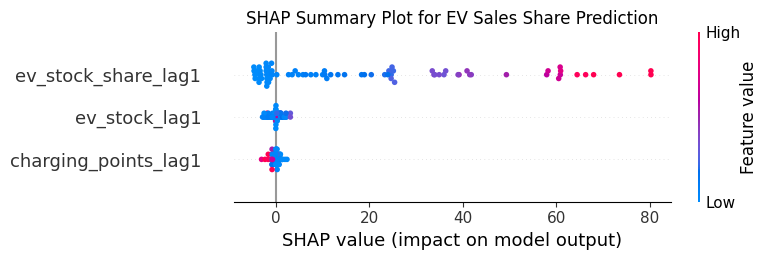


Mean Absolute SHAP Feature Importance:
                Feature  Mean_Absolute_SHAP
0   ev_stock_share_lag1           21.830763
1         ev_stock_lag1            1.024542
2  charging_points_lag1            0.625796


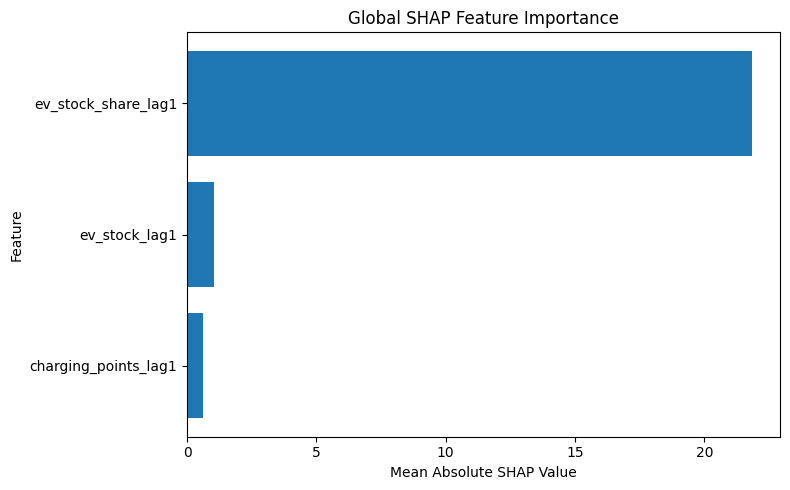

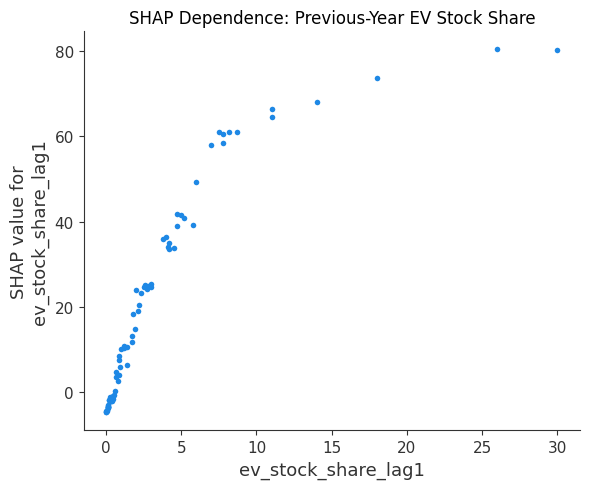

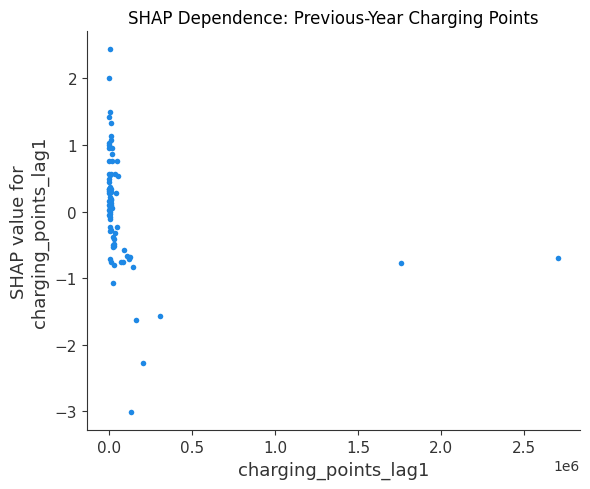

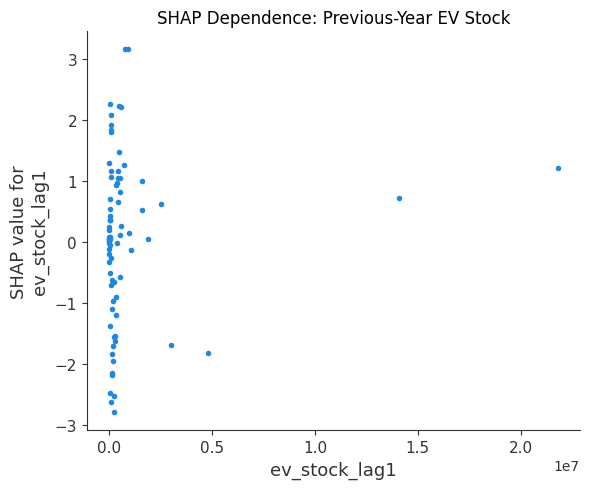


SHAP Test Results:
        country  year  actual_ev_sales_share  predicted_ev_sales_share  \
421   Australia  2023                  12.00                  6.193113   
422     Austria  2023                  27.00                 29.085255   
423     Belgium  2023                  41.00                 36.700108   
424      Brazil  2023                   3.00                  2.202327   
425      Canada  2023                  13.00                 18.886566   
426       Chile  2023                   0.75                  1.090266   
427       China  2023                  38.00                 46.385662   
428    Colombia  2023                   3.90                  4.057763   
429  Costa Rica  2023                  13.00                  4.932558   
430     Denmark  2023                  46.00                 61.731316   

     absolute_error  ev_stock_lag1_shap  ev_stock_share_lag1_shap  \
421        5.806887            1.157287                  0.247008   
422        2.085255        

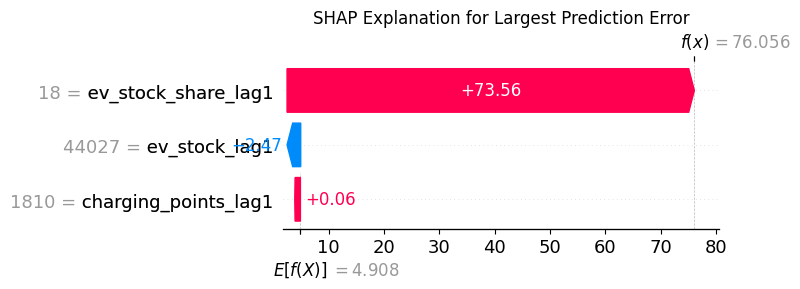


Observation with Smallest Prediction Error:
country                      South Africa
year                                 2024
actual_ev_sales_share                0.61
predicted_ev_sales_share         0.601173
absolute_error                   0.008827
ev_stock_lag1_shap              -0.027083
ev_stock_share_lag1_shap        -4.376493
charging_points_lag1_shap        0.096536
Name: 490, dtype: object


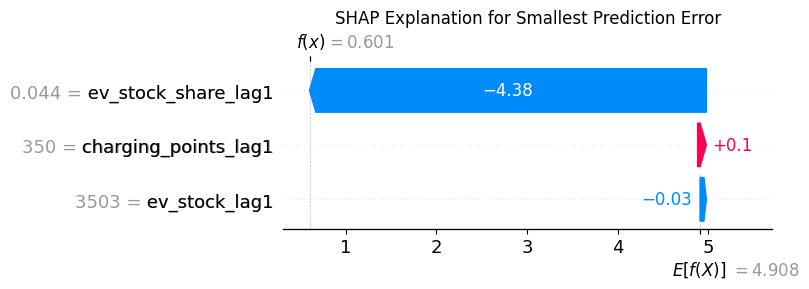


SHAP vs XGBoost Built-in Feature Importance:
                Feature  Mean_Absolute_SHAP  XGBoost_Importance
0   ev_stock_share_lag1           21.830763            0.956865
1         ev_stock_lag1            1.024542            0.020277
2  charging_points_lag1            0.625796            0.022859


In [2]:
# ============================================================
# SHAP EXPLAINABILITY
# Explaining the Final Tuned XGBoost Model
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from xgboost import XGBRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)


file_path = "../data/processed/feature_engineered_ev_dataset.csv"

master_df = pd.read_csv(file_path)


# ============================================================
# 2. DEFINE FEATURES AND TARGET
# ============================================================

features = [
    "ev_stock_lag1",
    "ev_stock_share_lag1",
    "charging_points_lag1"
]

target = "ev_sales_share"


# ============================================================
# 3. CREATE SHAP MODELLING DATAFRAME
# ============================================================

shap_df = master_df[
    [
        "country",
        "year",
        "ev_stock_lag1",
        "ev_stock_share_lag1",
        "charging_points_lag1",
        "ev_sales_share"
    ]
].dropna().copy()


# Keep the same ordering used in the final XGBoost model

shap_df = (
    shap_df
    .sort_values(
        ["year", "country"]
    )
    .reset_index(drop=True)
)


print("SHAP modelling dataset shape:")
print(shap_df.shape)


print("\nMissing values:")
print(shap_df.isnull().sum())


print("\nYears available:")
print(
    sorted(
        shap_df["year"].unique()
    )
)


# ============================================================
# 4. CREATE TIME-BASED TRAIN / TEST SPLIT
# ============================================================

shap_train_df = shap_df[
    shap_df["year"] <= 2022
].copy()


shap_test_df = shap_df[
    shap_df["year"].isin(
        [2023, 2024]
    )
].copy()


print("\nTraining dataset shape:")
print(shap_train_df.shape)


print("\nTesting dataset shape:")
print(shap_test_df.shape)


print("\nTraining years:")
print(
    sorted(
        shap_train_df["year"].unique()
    )
)


print("\nTesting years:")
print(
    sorted(
        shap_test_df["year"].unique()
    )
)


# ============================================================
# 5. CREATE TRAINING AND TEST VARIABLES
# ============================================================

X_train = shap_train_df[
    features
]


y_train = shap_train_df[
    target
]


X_test = shap_test_df[
    features
]


y_test = shap_test_df[
    target
]


print("\nX_train shape:")
print(X_train.shape)


print("\nX_test shape:")
print(X_test.shape)


# ============================================================
# 6. RECREATE FINAL TUNED XGBOOST MODEL
# ============================================================

final_xgb_model = XGBRegressor(
    colsample_bytree=1.0,
    learning_rate=0.05,
    max_depth=5,
    n_estimators=300,
    subsample=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=1
)


# ============================================================
# 7. TRAIN FINAL XGBOOST MODEL
# ============================================================

final_xgb_model.fit(
    X_train,
    y_train
)


# ============================================================
# 8. VERIFY FINAL MODEL PERFORMANCE
# ============================================================

y_pred = final_xgb_model.predict(
    X_test
)


final_r2 = r2_score(
    y_test,
    y_pred
)


final_mae = mean_absolute_error(
    y_test,
    y_pred
)


final_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)


print("\nFinal XGBoost Performance Verification")

print(
    f"R²   : {final_r2:.4f}"
)

print(
    f"MAE  : {final_mae:.4f}"
)

print(
    f"RMSE : {final_rmse:.4f}"
)


# ============================================================
# 9. CREATE SHAP EXPLAINER
# ============================================================

explainer = shap.TreeExplainer(
    final_xgb_model
)


# ============================================================
# 10. CALCULATE SHAP VALUES FOR TEST DATA
# ============================================================

shap_values = explainer(
    X_test
)


print("\nSHAP values shape:")

print(
    shap_values.values.shape
)


print("\nSHAP base value:")

print(
    shap_values.base_values[0]
)


# ============================================================
# 11. VERIFY SHAP ADDITIVE PROPERTY
# ============================================================

shap_prediction_check = (

    shap_values.base_values

    +

    shap_values.values.sum(
        axis=1
    )

)


shap_verification_df = pd.DataFrame({

    "Model_Prediction":
        y_pred,

    "SHAP_Reconstructed_Prediction":
        shap_prediction_check,

    "Difference":
        y_pred
        -
        shap_prediction_check

})


print(
    "\nSHAP Prediction Reconstruction Check:"
)


print(
    shap_verification_df.head(10)
)


print(
    "\nMaximum SHAP Reconstruction Difference:"
)


print(
    np.abs(
        shap_verification_df[
            "Difference"
        ]
    ).max()
)


# ============================================================
# 12. SHAP SUMMARY BEESWARM PLOT
# ============================================================

shap.summary_plot(
    shap_values.values,
    X_test,
    feature_names=features,
    show=False
)


plt.title(
    "SHAP Summary Plot for EV Sales Share Prediction"
)


plt.tight_layout()


plt.show()


# ============================================================
# 13. CALCULATE MEAN ABSOLUTE SHAP VALUES
# ============================================================

mean_absolute_shap = np.abs(
    shap_values.values
).mean(
    axis=0
)


shap_importance_df = pd.DataFrame({

    "Feature": features,

    "Mean_Absolute_SHAP":
        mean_absolute_shap

})


shap_importance_df = (

    shap_importance_df

    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )

    .reset_index(drop=True)

)


print(
    "\nMean Absolute SHAP Feature Importance:"
)


print(
    shap_importance_df
)


# ============================================================
# 14. MEAN ABSOLUTE SHAP IMPORTANCE PLOT
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.barh(

    shap_importance_df[
        "Feature"
    ],

    shap_importance_df[
        "Mean_Absolute_SHAP"
    ]

)


plt.xlabel(
    "Mean Absolute SHAP Value"
)


plt.ylabel(
    "Feature"
)


plt.title(
    "Global SHAP Feature Importance"
)


plt.gca().invert_yaxis()


plt.tight_layout()


plt.show()


# ============================================================
# 15. SHAP DEPENDENCE PLOT:
# PREVIOUS-YEAR EV STOCK SHARE
# ============================================================

shap.dependence_plot(

    "ev_stock_share_lag1",

    shap_values.values,

    X_test,

    interaction_index=None,

    show=False

)


plt.title(
    "SHAP Dependence: Previous-Year EV Stock Share"
)


plt.tight_layout()


plt.show()


# ============================================================
# 16. SHAP DEPENDENCE PLOT:
# PREVIOUS-YEAR CHARGING POINTS
# ============================================================

shap.dependence_plot(

    "charging_points_lag1",

    shap_values.values,

    X_test,

    interaction_index=None,

    show=False

)


plt.title(
    "SHAP Dependence: Previous-Year Charging Points"
)


plt.tight_layout()


plt.show()


# ============================================================
# 17. SHAP DEPENDENCE PLOT:
# PREVIOUS-YEAR EV STOCK
# ============================================================

shap.dependence_plot(

    "ev_stock_lag1",

    shap_values.values,

    X_test,

    interaction_index=None,

    show=False

)


plt.title(
    "SHAP Dependence: Previous-Year EV Stock"
)


plt.tight_layout()


plt.show()


# ============================================================
# 18. CREATE TEST EXPLANATION DATAFRAME
# ============================================================

shap_results_df = shap_test_df[
    [
        "country",
        "year"
    ]
].copy()


shap_results_df[
    "actual_ev_sales_share"
] = y_test.values


shap_results_df[
    "predicted_ev_sales_share"
] = y_pred


shap_results_df[
    "absolute_error"
] = np.abs(
    y_test.values
    -
    y_pred
)


for feature_index, feature_name in enumerate(
    features
):

    shap_results_df[
        f"{feature_name}_shap"
    ] = shap_values.values[
        :,
        feature_index
    ]


print(
    "\nSHAP Test Results:"
)


print(
    shap_results_df.head(10)
)


# ============================================================
# 19. IDENTIFY LARGEST PREDICTION ERROR
# ============================================================

largest_error_index = (

    shap_results_df[
        "absolute_error"
    ]

    .idxmax()

)


largest_error_position = (

    shap_results_df.index

    .get_loc(
        largest_error_index
    )

)


largest_error_row = (

    shap_results_df.loc[
        largest_error_index
    ]

)


print(
    "\nObservation with Largest Prediction Error:"
)


print(
    largest_error_row
)


# ============================================================
# 20. SHAP WATERFALL PLOT:
# LARGEST PREDICTION ERROR
# ============================================================

shap.plots.waterfall(

    shap_values[
        largest_error_position
    ],

    max_display=3,

    show=False

)


plt.title(
    "SHAP Explanation for Largest Prediction Error"
)


plt.tight_layout()


plt.show()


# ============================================================
# 21. IDENTIFY BEST PREDICTION
# ============================================================

best_prediction_index = (

    shap_results_df[
        "absolute_error"
    ]

    .idxmin()

)


best_prediction_position = (

    shap_results_df.index

    .get_loc(
        best_prediction_index
    )

)


best_prediction_row = (

    shap_results_df.loc[
        best_prediction_index
    ]

)


print(
    "\nObservation with Smallest Prediction Error:"
)


print(
    best_prediction_row
)


# ============================================================
# 22. SHAP WATERFALL PLOT:
# BEST PREDICTION
# ============================================================

shap.plots.waterfall(

    shap_values[
        best_prediction_position
    ],

    max_display=3,

    show=False

)


plt.title(
    "SHAP Explanation for Smallest Prediction Error"
)


plt.tight_layout()


plt.show()


# ============================================================
# 23. COMPARE SHAP IMPORTANCE WITH
# XGBOOST BUILT-IN FEATURE IMPORTANCE
# ============================================================

xgb_builtin_importance_df = pd.DataFrame({

    "Feature": features,

    "XGBoost_Importance":
        final_xgb_model.feature_importances_

})


importance_comparison_df = pd.merge(

    shap_importance_df,

    xgb_builtin_importance_df,

    on="Feature"

)


importance_comparison_df = (

    importance_comparison_df

    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )

    .reset_index(drop=True)

)


print(
    "\nSHAP vs XGBoost Built-in Feature Importance:"
)


print(
    importance_comparison_df
)